In [6]:
import pandas as pd

In [9]:
df=pd.read_csv("Avocado.csv")
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [10]:
df.columns

Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  str    
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  str    
 12  year          18249 non-null  int64  
 13  region        18249 non-null  str    
dtypes: float64(9), int64(2), str(3)
memory usage: 2.5 MB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,18249.0,24.232232,1.548104e+01,0.00,10.00,24.00,38.00,52.00
AveragePrice,18249.0,1.405978,4.026766e-01,0.44,1.10,1.37,1.66,3.25
Total Volume,18249.0,850644.013009,3.453545e+06,84.56,10838.58,107376.76,432962.29,62505646.52
4046,18249.0,293008.424531,1.264989e+06,0.00,854.07,8645.30,111020.20,22743616.17
4225,18249.0,295154.568356,1.204120e+06,0.00,3008.78,29061.02,150206.86,20470572.61
4770,18249.0,22839.735993,1.074641e+05,0.00,0.00,184.99,6243.42,2546439.11
Total Bags,18249.0,239639.202060,9.862424e+05,0.00,5088.64,39743.83,110783.37,19373134.37
Small Bags,18249.0,182194.686696,7.461785e+05,0.00,2849.42,26362.82,83337.67,13384586.80
Large Bags,18249.0,54338.088145,2.439660e+05,0.00,127.47,2647.71,22029.25,5719096.61
XLarge Bags,18249.0,3106.426507,1.769289e+04,0.00,0.00,0.00,132.50,551693.65


In [13]:
df.isnull().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [16]:
df["type"].value_counts()


type
conventional    9126
organic         9123
Name: count, dtype: int64

In [17]:
df["region"].value_counts()

region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
LasVegas               338
LosAngeles             338
Louisville             338
MiamiFtLauderdale      338
Midsouth               338
Nashville              338
NewOrleansMobile       338
NewYork                338
Northeast              338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338
Portland             

In [18]:
df["Date"].head()

0    2015-12-27
1    2015-12-20
2    2015-12-13
3    2015-12-06
4    2015-11-29
Name: Date, dtype: str

In [19]:
df.dtypes

Date                str
AveragePrice    float64
Total Volume    float64
4046            float64
4225            float64
4770            float64
Total Bags      float64
Small Bags      float64
Large Bags      float64
XLarge Bags     float64
type                str
year              int64
region              str
dtype: object

In [20]:
df["Date"] = pd.to_datetime(df["Date"])

In [21]:
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [22]:
df.drop("Date", axis=1, inplace=True)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

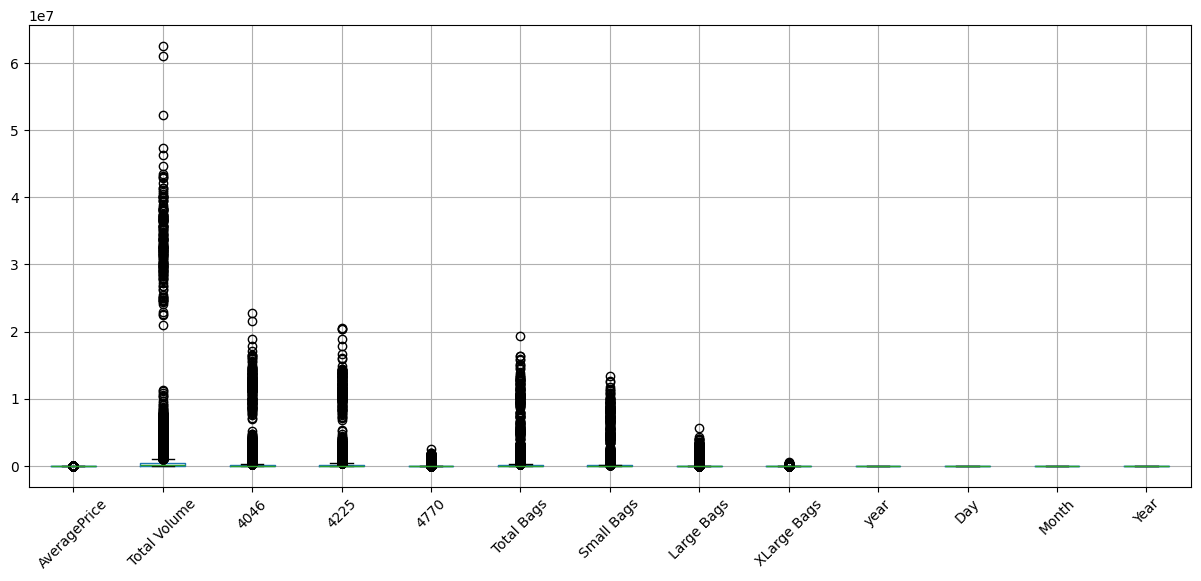

In [24]:
df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [25]:
def count_outliers_iqr(df, thresh=1.5):
    result = []
    for col in df.select_dtypes(include=["int64","float64"]).columns:

        if col == "AveragePrice":
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - thresh * IQR
        upper = Q3 + thresh * IQR

        count = ((df[col] < lower) | (df[col] > upper)).sum()

        result.append([col, count])

    return pd.DataFrame(result, columns=["Column","Outlier_Count"])

In [26]:
outlier_report = count_outliers_iqr(df)
outlier_report

,Column,Outlier_Count
0,Total Volume,2297
1,4046,2518
2,4225,2519
3,4770,2918
4,Total Bags,2533
5,Small Bags,2407
6,Large Bags,2707
7,XLarge Bags,4014
8,year,0


In [27]:
df["type"].value_counts()

type
conventional    9126
organic         9123
Name: count, dtype: int64

In [28]:
df["region"].value_counts()

region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
LasVegas               338
LosAngeles             338
Louisville             338
MiamiFtLauderdale      338
Midsouth               338
Nashville              338
NewOrleansMobile       338
NewYork                338
Northeast              338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338
Portland             

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])


In [30]:
df["type"].value_counts()

type
0    9126
1    9123
Name: count, dtype: int64

In [31]:
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

In [32]:
df.dtypes

AveragePrice               float64
Total Volume               float64
4046                       float64
4225                       float64
4770                       float64
                            ...   
region_Syracuse              int64
region_Tampa                 int64
region_TotalUS               int64
region_West                  int64
region_WestTexNewMexico      int64
Length: 67, dtype: object

In [33]:
X = df.drop("AveragePrice", axis=1)
y = df["AveragePrice"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14599, 66)
(3650, 66)
(14599,)
(3650,)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
y_pred = model.predict(X_test_scaled)
y_pred

array([1.016857  , 1.1893518 , 1.55631507, ..., 0.85938303, 1.77088555,
       2.04561044], shape=(3650,))

In [39]:
print("Training Score:", model.score(X_train_scaled, y_train))
print("Testing Score:", model.score(X_test_scaled, y_test))

Training Score: 0.5916385940715823
Testing Score: 0.587843646620521


In [48]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [49]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 0.19464779933358728
MSE : 0.0662207834810451
RMSE : 0.2573339920823619
R2 Score : 0.587843646620521


In [50]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("R² Score of each fold:", scores)
print("Mean R² Score:", scores.mean())
print("Standard Deviation:", scores.std())

R² Score of each fold: [0.58960097 0.60361575 0.59660502 0.58031508 0.56706795]
Mean R² Score: 0.5874409569106879
Standard Deviation: 0.01277581341522179


In [51]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'alpha': 1}
Best Cross Validation Score: 0.5875008770759538


In [52]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

from sklearn.metrics import r2_score

print("Test R² Score:", r2_score(y_test, y_pred))

Test R² Score: 0.5879415813614132


In [53]:
import pickle

with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)    